<div align="center">

# ***EDA OF CUSTOMER CHURN KAGGLE CHALLENGE S6E3***

</div>

## LIBRARY

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import optuna
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, TargetEncoder, OneHotEncoder
from tqdm import tqdm
import mlflow
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import os

## EDA

In [2]:
data_path = Path("../src/data/raw/train.csv")  # EDA.ipynb is in /notebooks
data = pd.read_csv(data_path)

In [3]:
data.set_index("id", inplace=True)

In [4]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

gender: 2 unique values


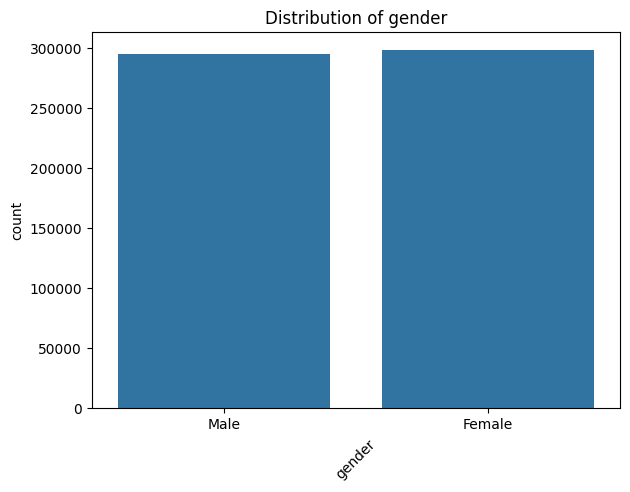

SeniorCitizen: 2 unique values


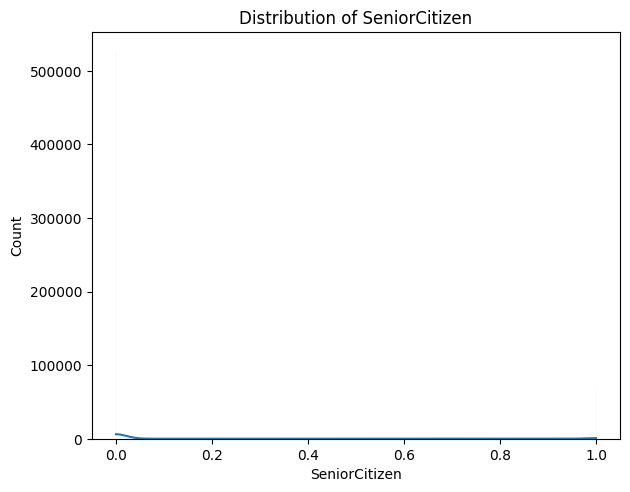

Partner: 2 unique values


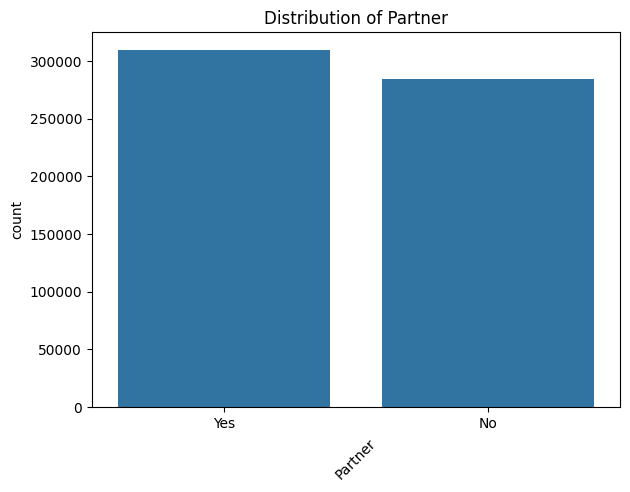

Dependents: 2 unique values


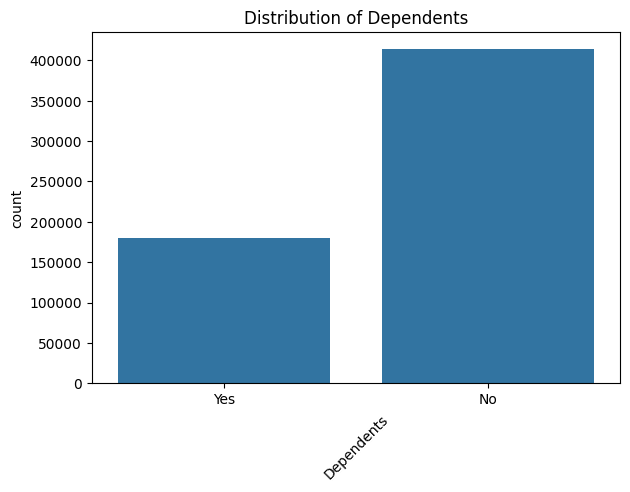

tenure: 72 unique values


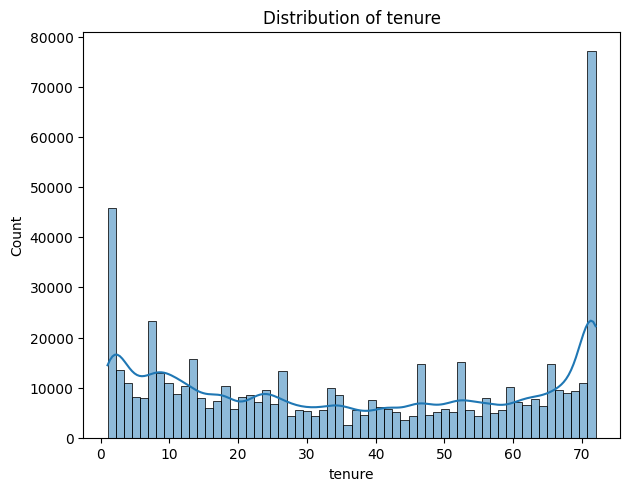

PhoneService: 2 unique values


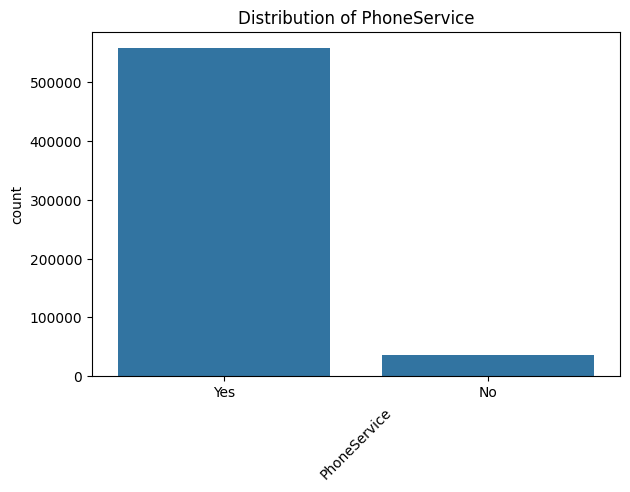

MultipleLines: 3 unique values


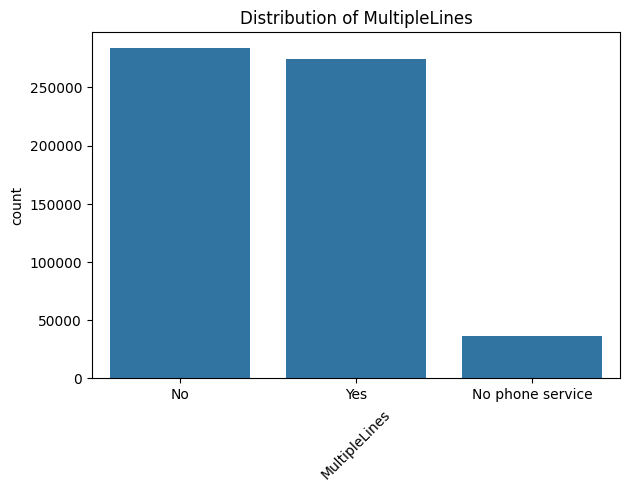

InternetService: 3 unique values


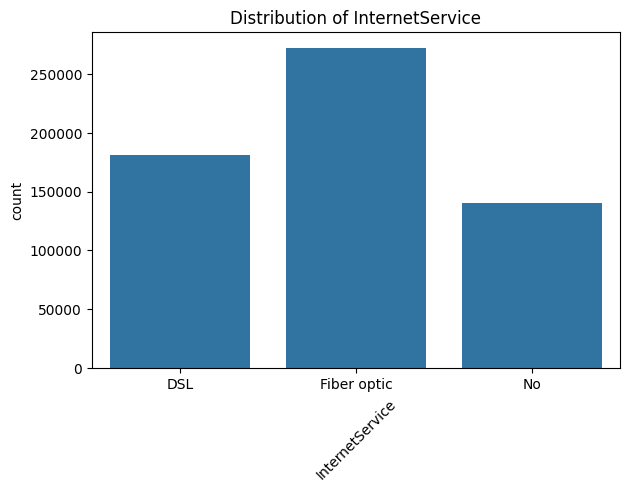

OnlineSecurity: 3 unique values


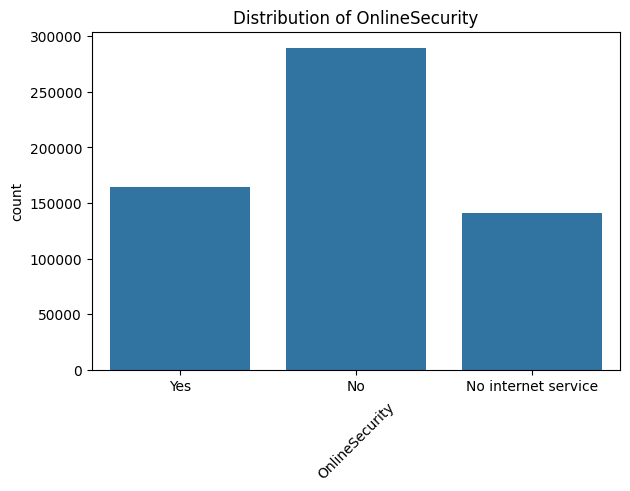

OnlineBackup: 3 unique values


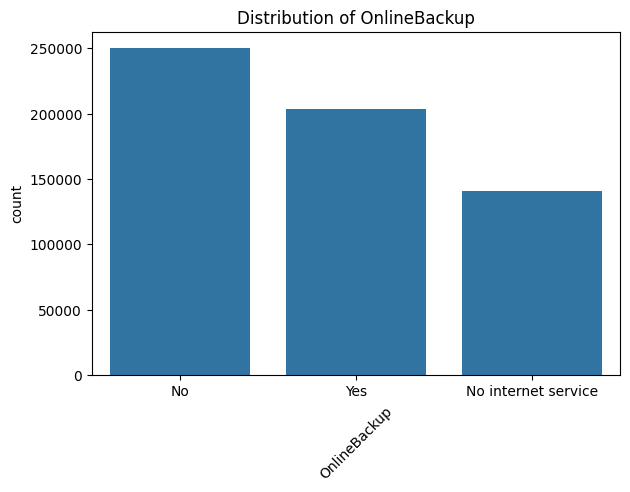

DeviceProtection: 3 unique values


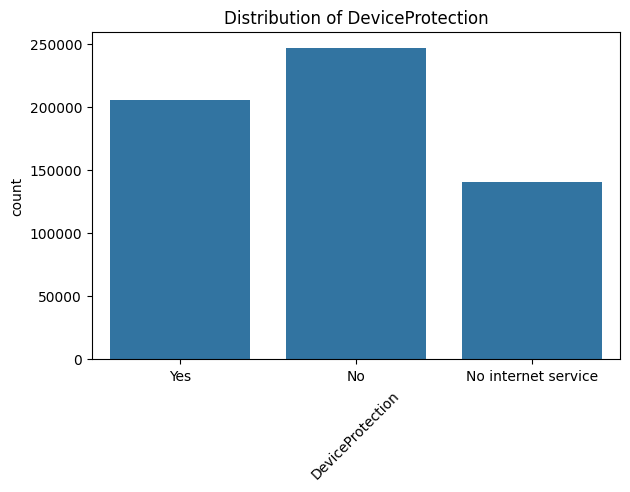

TechSupport: 3 unique values


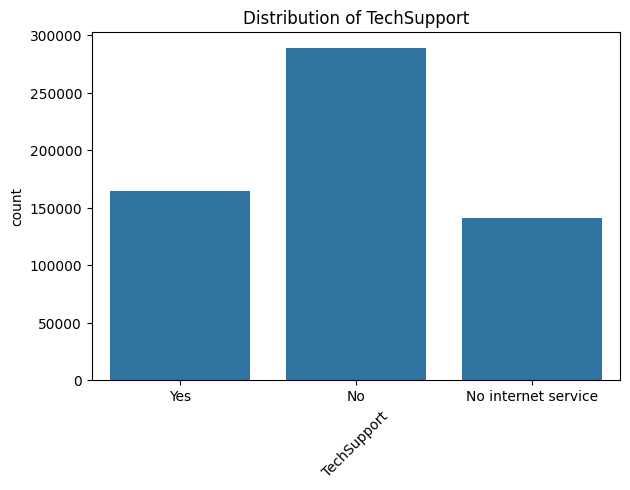

StreamingTV: 3 unique values


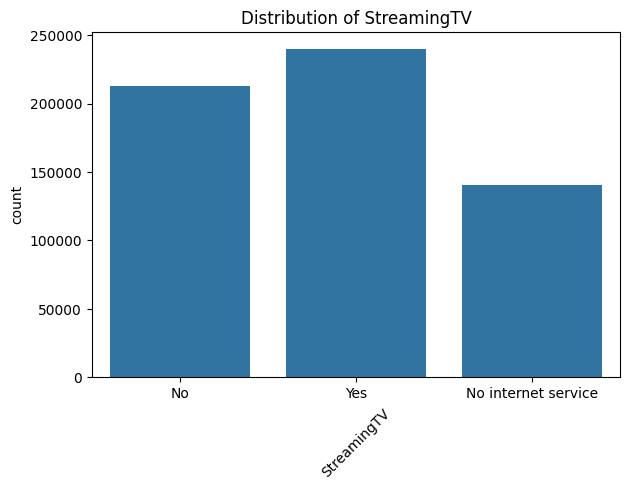

StreamingMovies: 3 unique values


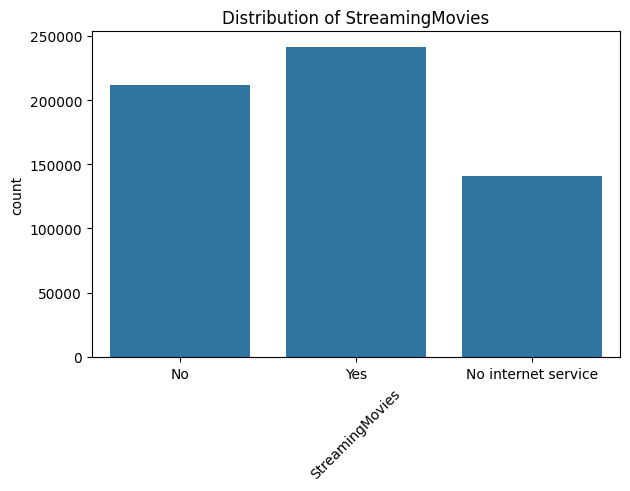

Contract: 3 unique values


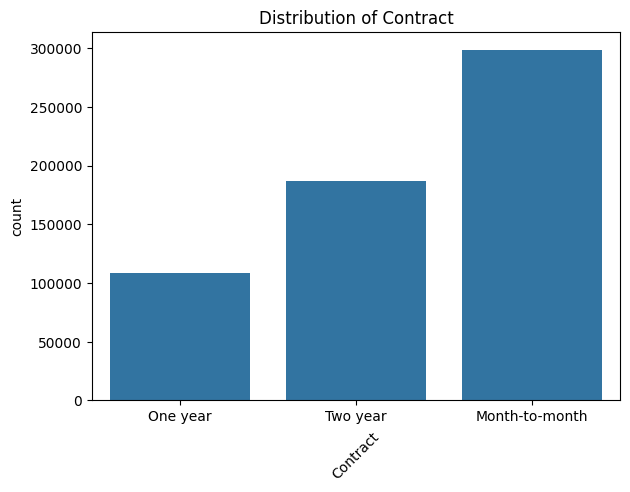

PaperlessBilling: 2 unique values


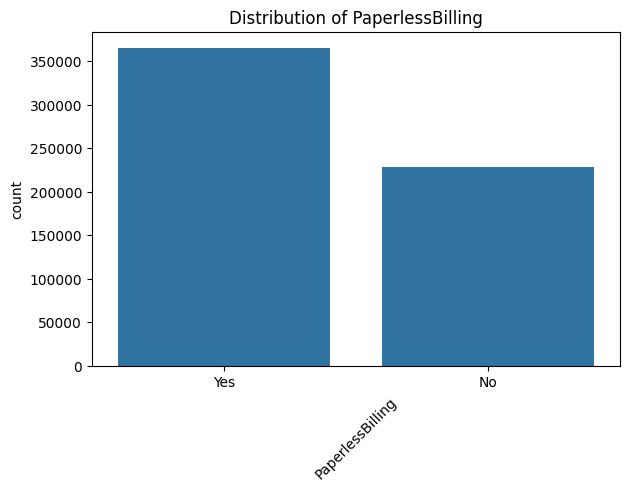

PaymentMethod: 4 unique values


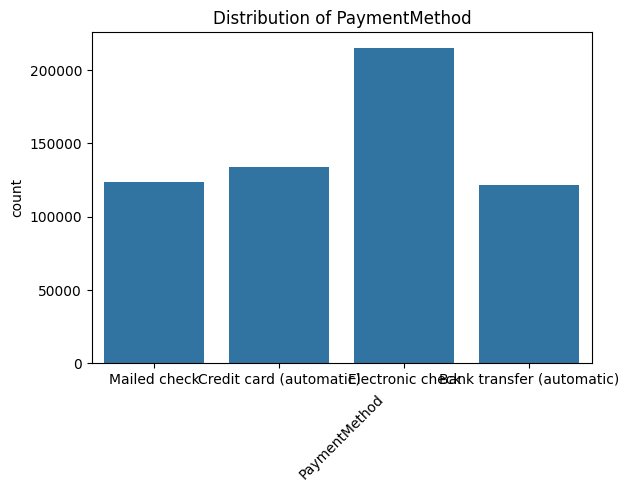

MonthlyCharges: 1921 unique values


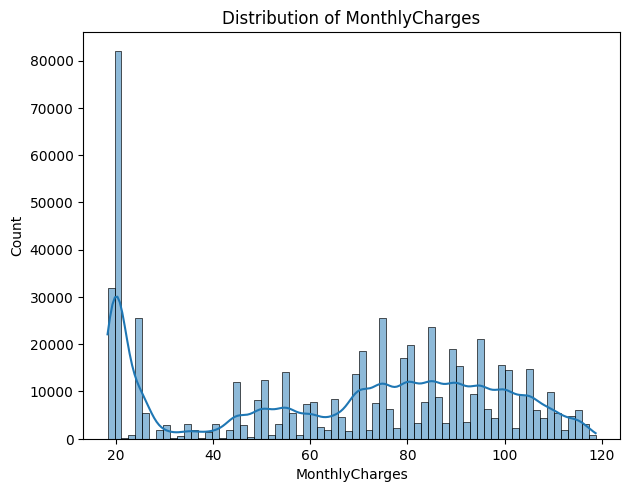

TotalCharges: 31910 unique values


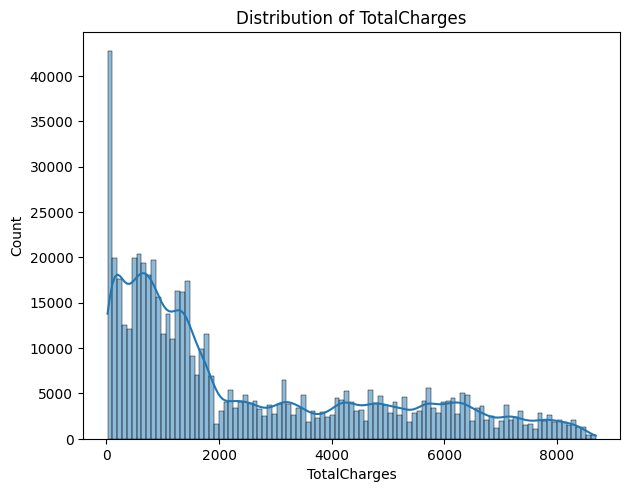

Churn: 2 unique values


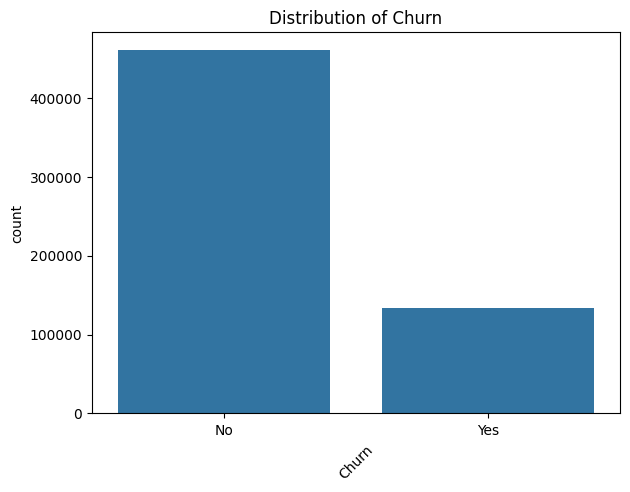

In [7]:
for col in data.columns:
    if data[col].dtype == "object":
        print(f"{col}: {data[col].nunique()} unique values")
        sns.countplot(x=col, data=data)
        plt.xlabel(col, rotation=45)
        plt.tight_layout()
        plt.title(f"Distribution of {col}")
        plt.show()
    elif data[col].dtype in ["int64", "float64"]:
        print(f"{col}: {data[col].nunique()} unique values")
        sns.histplot(x=col, data=data, kde=True)
        plt.xlabel(col)
        plt.tight_layout()
        plt.title(f"Distribution of {col}")
        plt.show()

<Axes: xlabel='SeniorCitizen', ylabel='count'>

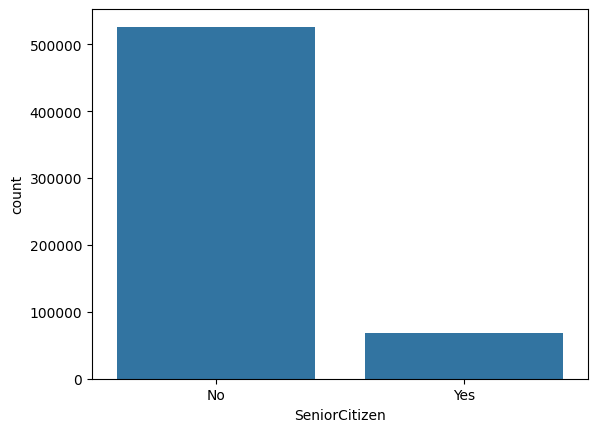

In [8]:
data_v2 = data.copy()
data_v2["SeniorCitizen"] = data_v2["SeniorCitizen"].map({0: "No", 1: "Yes"})
sns.countplot(x="SeniorCitizen", data=data_v2)

In [9]:
data_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  object 
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

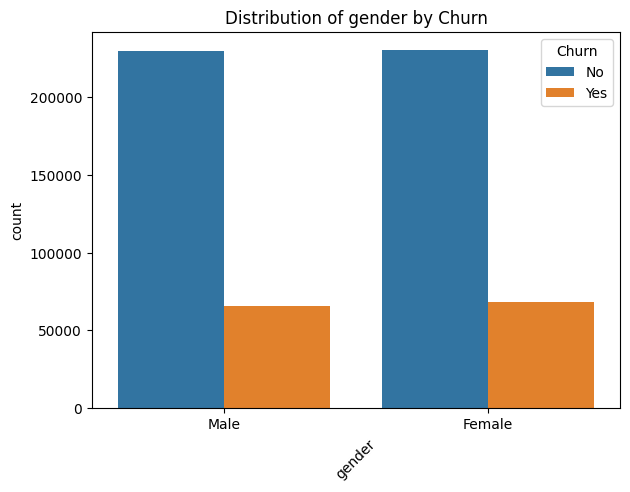

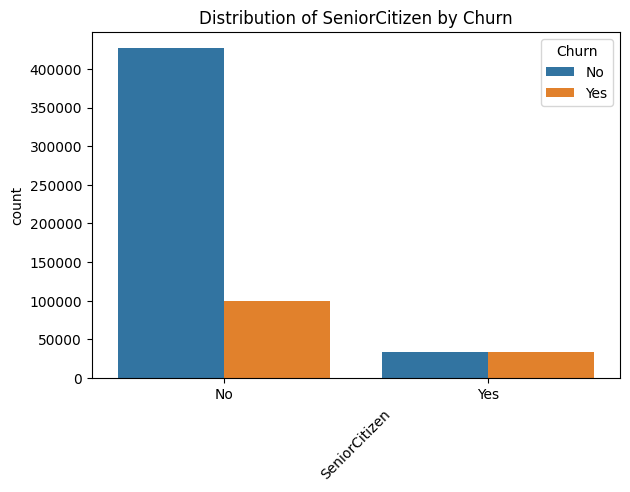

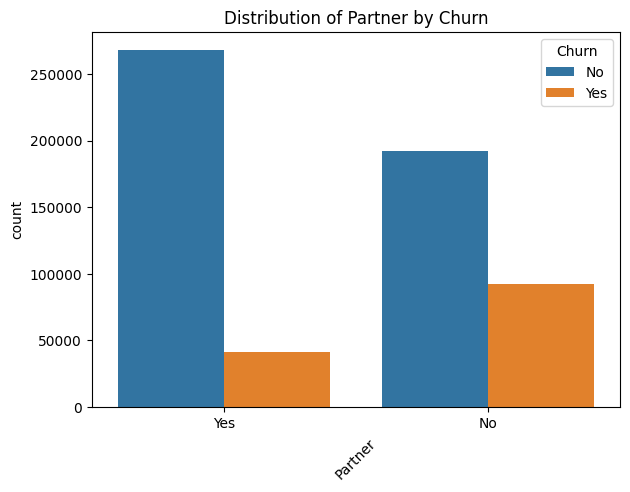

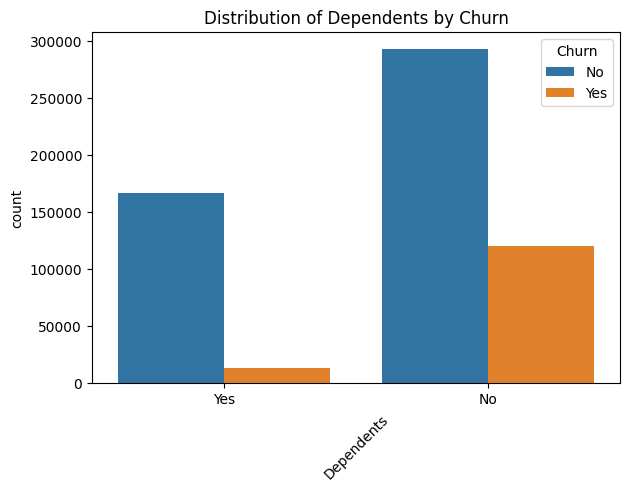

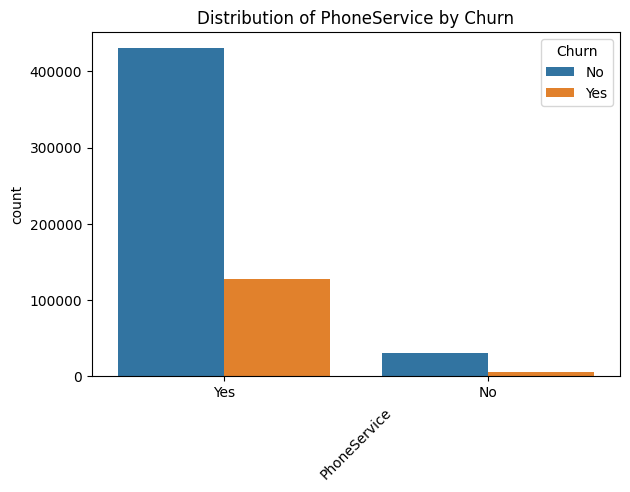

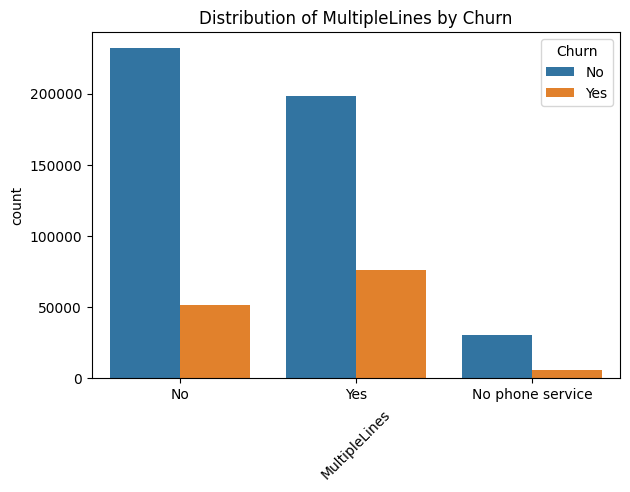

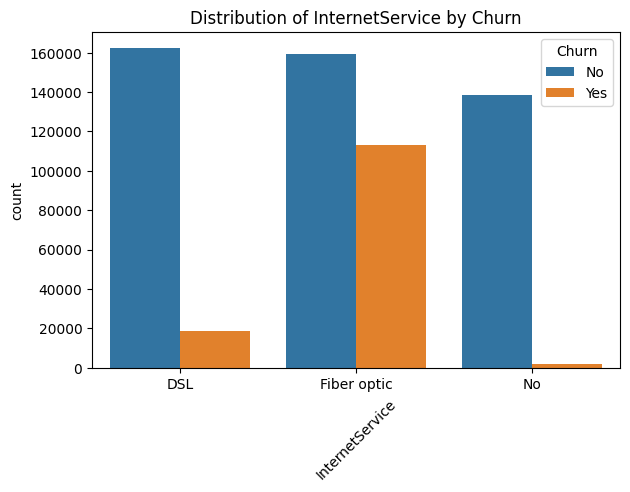

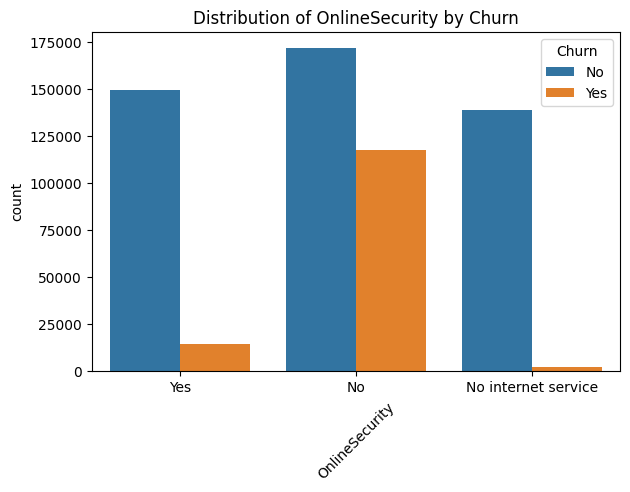

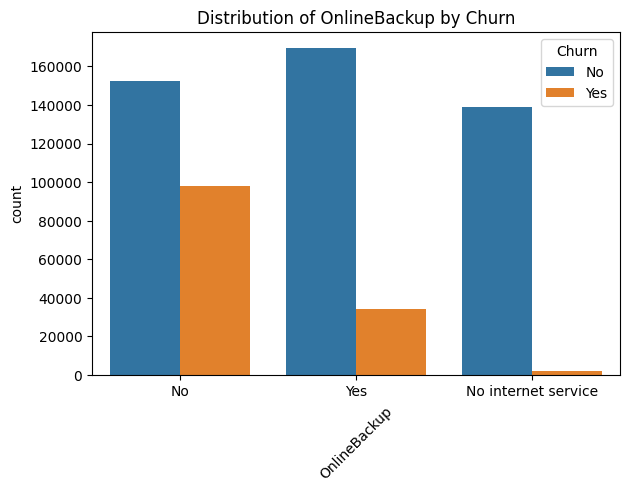

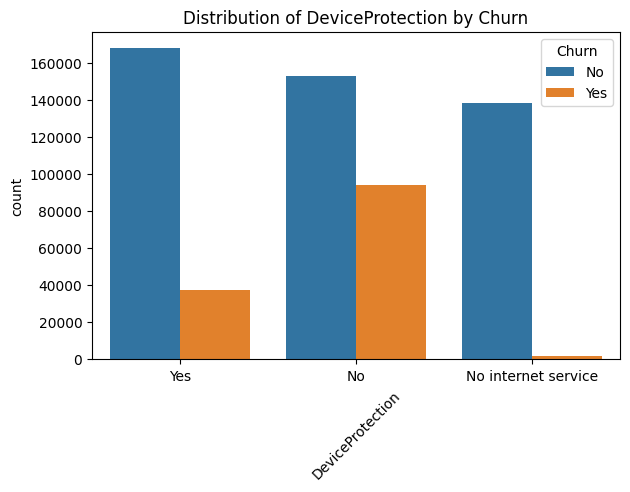

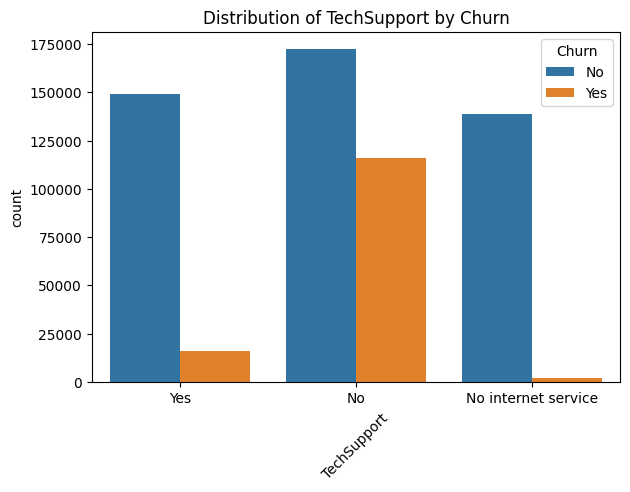

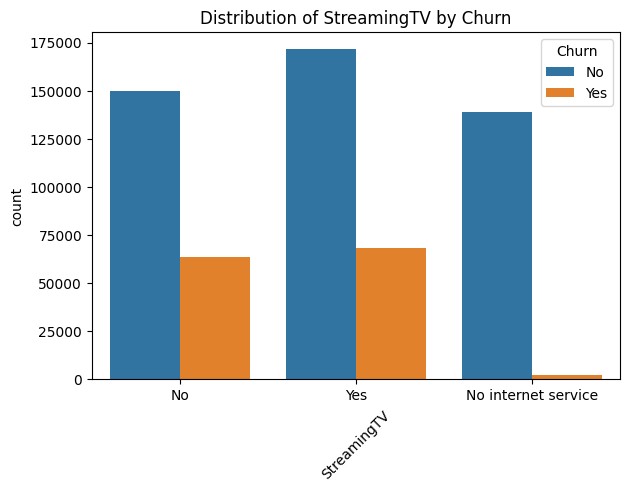

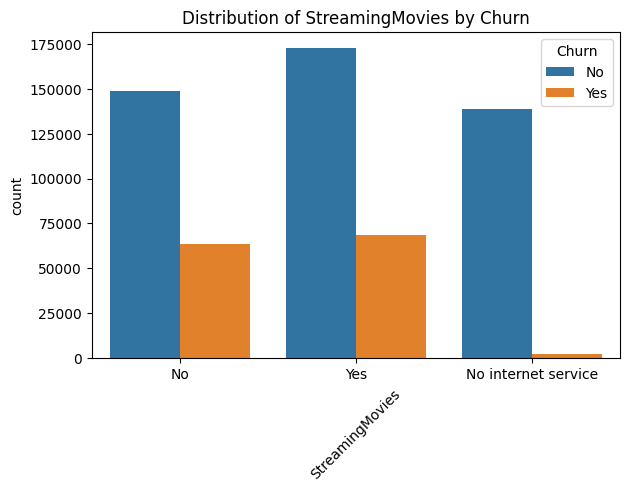

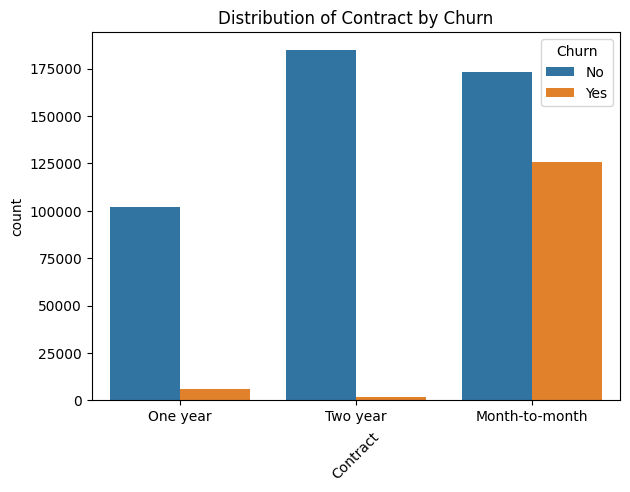

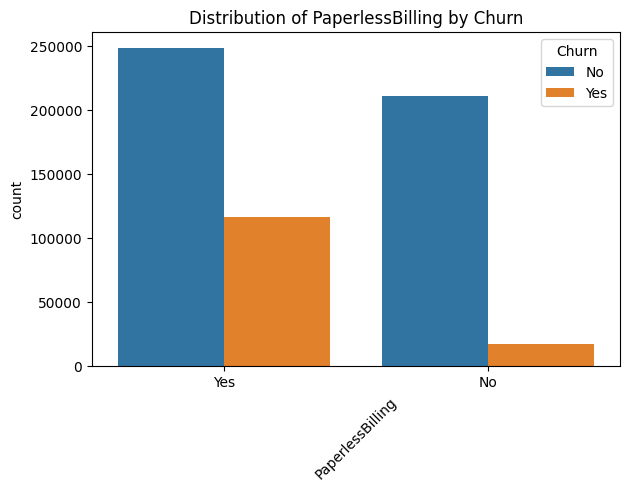

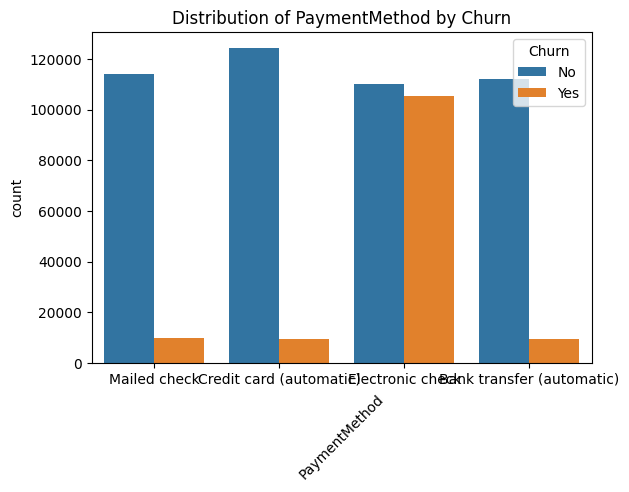

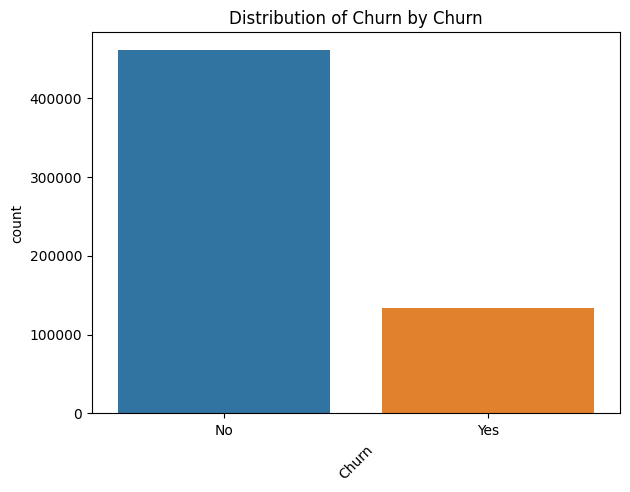

In [10]:
for col in data_v2.columns:
    if data_v2[col].dtype == "object":
        sns.countplot(x=col, data=data_v2, hue="Churn")
        plt.xlabel(col, rotation=45)
        plt.tight_layout()
        plt.title(f"Distribution of {col} by Churn")
        plt.show()

In [11]:
categorical_cols = data_v2.select_dtypes(include="object").columns.difference(["Churn"])
numerical_cols = data_v2.select_dtypes(include=["int64", "float64"]).columns
target_col = "Churn"

In [12]:
data_v2_encoded = data_v2.copy()
data_v2_encoded = pd.get_dummies(data_v2_encoded, columns=categorical_cols, drop_first=False)

In [13]:
data_v2_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,Dependents_No,Dependents_Yes,DeviceProtection_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,gender_Female,gender_Male
id,,,,,,,,,,,,,,,,,,,,,
0,29,60.10,1653.85,No,False,True,False,False,True,False,...,False,False,True,False,False,False,False,True,False,True
1,58,69.50,3778.20,No,False,False,True,False,True,True,...,False,False,False,False,True,False,False,True,False,True
2,58,100.40,5841.35,No,True,False,False,True,False,True,...,False,True,False,False,True,True,False,False,False,True
3,1,69.70,70.70,Yes,True,False,False,True,False,True,...,False,False,True,False,False,True,False,False,True,False
4,1,70.45,70.45,Yes,True,False,False,True,False,True,...,False,False,True,False,False,True,False,False,True,False


In [14]:
X = data_v2_encoded.drop(columns=[target_col])
y = data_v2_encoded[target_col].map({"No": 0, "Yes": 1})

In [17]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("MLflow Decision Tree Baseline")
mlflow.sklearn.autolog()

2026/03/18 00:32:46 INFO mlflow.tracking.fluent: Experiment with name 'MLflow Decision Tree Baseline' does not exist. Creating a new experiment.


In [20]:
with mlflow.start_run(run_name="Decision Tree Baseline"):
    DTC_v1 = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=10, min_samples_leaf=5, class_weight="balanced")
    cv_score = cross_val_score(DTC_v1, X, y, cv=5, scoring="roc_auc")
    print(f"Decision Tree CV AUC: {cv_score.mean():.4f} ± {cv_score.std():.4f}")

2026/03/18 00:37:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Kaggle\Customer Churn S6E3\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/18 00:37:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Kaggle\Customer Churn S6E3\venv\Lib\site-p

Decision Tree CV AUC: 0.9083 ± 0.0015
🏃 View run Decision Tree Baseline at: http://localhost:5000/#/experiments/2/runs/5d12f40b1f0142d79d90e3bc7bfe7a8f
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
DTC_v1.fit(X_train, y_train)

2026/03/18 00:41:30 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9d103013c4cd4a66aea3046bc2fbcfff', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/18 00:41:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Kaggle\Customer Churn S6E3\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Va

🏃 View run mercurial-rat-594 at: http://localhost:5000/#/experiments/2/runs/9d103013c4cd4a66aea3046bc2fbcfff
🧪 View experiment at: http://localhost:5000/#/experiments/2


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [26]:
submission_test_path = Path("../src/data/raw/test.csv")
submission_test = pd.read_csv(submission_test_path)
submission_test.set_index("id", inplace=True)
submission_test["SeniorCitizen"] = submission_test["SeniorCitizen"].map({0: "No", 1: "Yes"})
submission_test_processesd = pd.get_dummies(submission_test, columns=categorical_cols, drop_first=False)
submission_test_processesd.head()

,tenure,MonthlyCharges,TotalCharges,Contract_Month-to-month,Contract_One year,Contract_Two year,Dependents_No,Dependents_Yes,DeviceProtection_No,DeviceProtection_No internet service,...,StreamingMovies_No internet service,StreamingMovies_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,gender_Female,gender_Male
id,,,,,,,,,,,,,,,,,,,,,
594194,72,115.55,8061.50,False,False,True,True,False,False,False,...,False,True,False,False,True,False,False,True,True,False
594195,71,19.80,1336.50,False,False,True,True,False,False,True,...,True,False,False,True,False,False,True,False,True,False
594196,12,55.55,633.55,True,False,False,True,False,True,False,...,False,False,True,False,False,True,False,False,False,True
594197,71,84.10,6457.15,False,False,True,False,True,False,False,...,False,True,False,False,True,False,False,True,False,True
594198,15,90.35,1233.65,True,False,False,True,False,True,False,...,False,True,False,False,True,True,False,False,True,False


In [28]:
submission_test_file = DTC_v1.predict_proba(submission_test_processesd)[:, 1]
submission_df = pd.DataFrame({"id": submission_test_processesd.index, "Churn": submission_test_file})
submission_df.to_csv("../src/data/submission_kaggle/decision_tree_baseline.csv", index=False)

2026/03/18 00:47:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Kaggle\Customer Churn S6E3\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(X_train.columns, DTC_v1.feature_importances_)
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig("feature_importances.png")
mlflow.log_artifact("feature_importances.png")
plt.close()

In [37]:
importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': DTC_v1.feature_importances_
    }).sort_values('importance', ascending=False)
importance_df.to_csv("feature_importances.csv", index=False)
mlflow.log_artifact("feature_importances.csv")

In [ ]:
# 3. Add tree visualization
# plt.figure(figsize=(20, 10))
# plot_tree(DTC_v1, filled=True, feature_names=X_train.columns, 
#              class_names=['Class 0', 'Class 1'], rounded=True, fontsize=10)
# plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')
# mlflow.log_artifact("decision_tree.png")
# plt.close()
    
# 4. Add text representation
tree_text = export_text(DTC_v1, feature_names=X_train.columns)
with open("tree_structure.txt", "w") as f:
    f.write(tree_text)
mlflow.log_artifact("tree_structure.txt")